# New Section

importing dataset
 from kaggle

In [1]:
!pip install kagglehub -q
import kagglehub, pandas as pd, os

path = kagglehub.dataset_download("viratsharma18245/delhi-crime-dataset")
df = pd.read_csv(os.path.join(path, "crime.csv"))
print("path to file",path)
print(df.shape)
df.head()


100%|██████████| 7.10k/7.10k [00:00<00:00, 4.66MB/s]

Extracting files...
path to file /root/.cache/kagglehub/datasets/viratsharma18245/delhi-crime-dataset/versions/1
(166, 14)


,nm_pol,murder,rape,gangrape,robbery,theft,assualt murders,sexual harassement,totarea,totalcrime,long,lat,crime/area,area
0,CHITRANJAN PARK,2,6,1,35,442,19,7,2659329.537,512,77.24920,28.53632,192.529731,2.659330
1,DABRI,8,28,0,79,240,26,16,3401013.428,397,77.08600,28.61268,116.729912,3.401013
2,MALVIYA NAGAR,3,28,1,33,694,63,15,1379853.572,837,77.20418,28.52989,606.586102,1.379854
3,CHANDNI MAHAL,1,8,1,23,529,19,7,5570696.132,588,77.23608,28.64361,105.552338,5.570696
4,MODEL TOWN,0,4,1,45,393,9,14,2689157.085,466,77.19369,28.70257,173.288501,2.689157


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # Added import os

# Load data
# The original path was incorrect, using the 'path' variable from the previous cell
# which correctly identifies the dataset location.
df = pd.read_csv(os.path.join(path, "crime.csv"))

# Basic Info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:\n", df.describe())

Shape: (166, 14)

Columns:
 ['nm_pol', 'murder', 'rape', 'gangrape', 'robbery', 'theft', 'assualt murders', 'sexual harassement', 'totarea', 'totalcrime', 'long', 'lat', 'crime/area', 'area']

Data Types:
 nm_pol                 object
murder                  int64
rape                    int64
gangrape                int64
robbery                 int64
theft                   int64
assualt murders         int64
sexual harassement      int64
totarea               float64
totalcrime              int64
long                  float64
lat                   float64
crime/area            float64
area                  float64
dtype: object

Missing Values:
 nm_pol                0
murder                0
rape                  0
gangrape              0
robbery               0
theft                 0
assualt murders       0
sexual harassement    0
totarea               0
totalcrime            0
long                  0
lat                   0
crime/area            0
area                  0
dtype:

# New Section

EDA


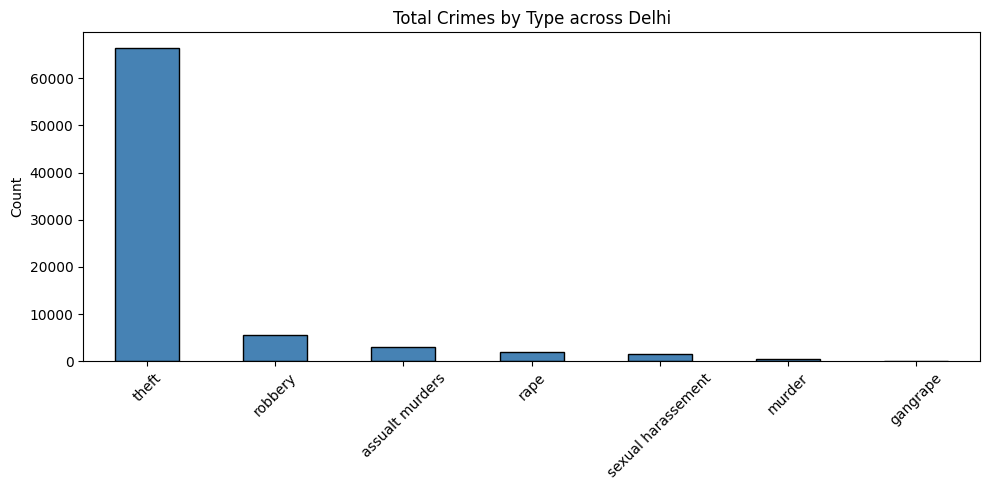

In [3]:

crime_cols = ['murder', 'rape', 'gangrape', 'robbery', 'theft', 'assualt murders', 'sexual harassement']  # adjust to your actual columns

df[crime_cols].sum().sort_values(ascending=False).plot(
    kind='bar', figsize=(10, 5), color='steelblue', edgecolor='black'
)
plt.title("Total Crimes by Type across Delhi")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

              nm_pol  totalcrime  crime/area
130  SUNLIGHT COLONY        1433  678.441541
18      PUNJABI BAGH        1421  551.349914
93       UTTAM NAGAR        1180  429.500812
132  NEW ASHOK NAGAR        1179  357.185602
31   BARAKHAMBA ROAD        1011  269.712057
84       MANDIR MARG         983   99.402778
77         NAJAFGARH         973  114.990112
99           NANGLOI         955  423.830077
72        MOTI NAGAR         949  301.403306
48     MAHENDRA PARK         918  372.615134


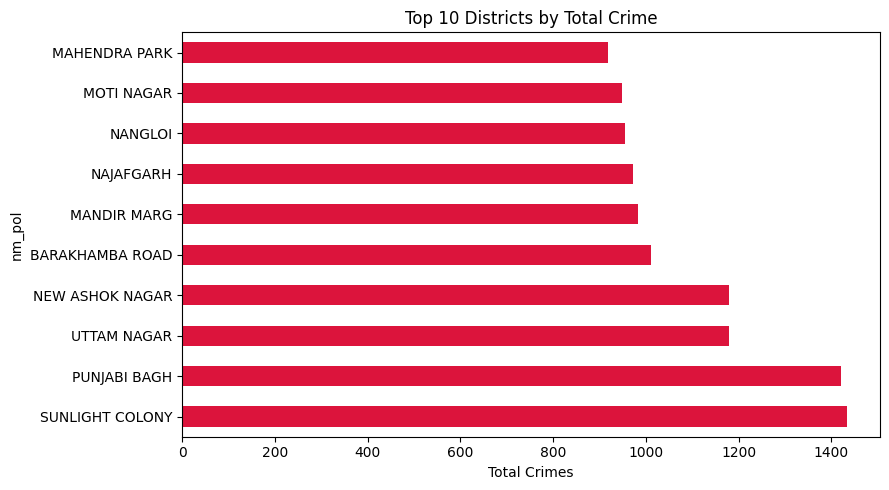

In [4]:

top10 = df.nlargest(10, 'totalcrime')[['nm_pol', 'totalcrime', 'crime/area']]
print(top10)

top10.set_index('nm_pol')['totalcrime'].plot(
    kind='barh', figsize=(9, 5), color='crimson'
)
plt.title("Top 10 Districts by Total Crime")
plt.xlabel("Total Crimes")
plt.tight_layout()
plt.show()

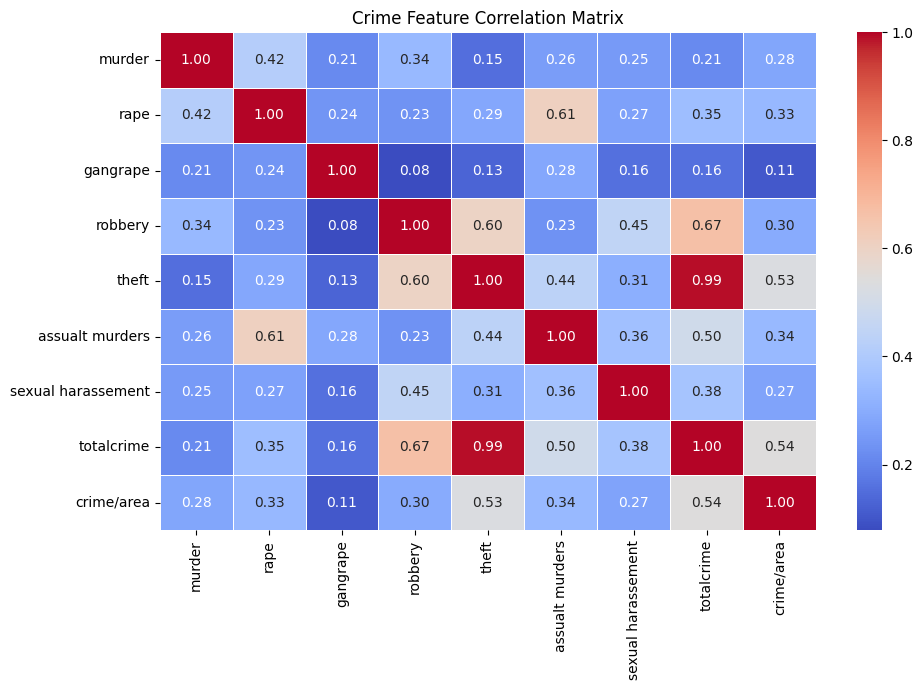

In [5]:

plt.figure(figsize=(10, 7))
sns.heatmap(df[crime_cols + ['totalcrime', 'crime/area']].corr(),
            annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Crime Feature Correlation Matrix")
plt.tight_layout()
plt.show()

feature engineering

# New Section

In [6]:
#  Feature Engineering

# 1. Severity Score (weighted — serious crimes get higher weight)
df['severity_score'] = (
    df['murder']   * 10 +
    df['rape']     * 9  +
    df['gangrape'] * 9  +
    df['robbery']  * 6  +
    df['assualt murders']  * 5  +
    df['sexual harassement'] * 7 +
    df['theft']    * 2
)

# 2. Crime Density (crimes per unit area)
df['crime_density'] = df['totalcrime'] / (df['area'] + 1e-5)

# 3. Violent Crime Ratio (violent vs total)
violent = df['murder'] + df['rape'] + df['gangrape'] + df['assualt murders']
df['violent_ratio'] = violent / (df['totalcrime'] + 1e-5)

# 4. Property Crime Ratio
df['property_ratio'] = (df['robbery'] + df['theft']) / (df['totalcrime'] + 1e-5)

# 5. Sexual Crime Ratio
df['sexual_ratio'] = (df['rape'] +  df['gangrape'] + df['sexual harassement']) / (df['totalcrime'] + 1e-5)

# 6. Risk Label for supervised learning (High / Medium / Low)
df['risk_label'] = pd.qcut(df['severity_score'], q=3, labels=['Low', 'Medium', 'High'])

print(df[['nm_pol', 'severity_score', 'crime_density',
          'violent_ratio', 'risk_label']].head(10))

               nm_pol  severity_score  crime_density  violent_ratio risk_label
0     CHITRANJAN PARK            1321     192.529007       0.054687     Medium
1               DABRI            1528     116.729569       0.156171       High
2       MALVIYA NAGAR            2297     606.581706       0.113501       High
3       CHANDNI MAHAL            1431     105.552148       0.049320     Medium
4          MODEL TOWN            1244     173.287857       0.030043     Medium
5          ANANDVIHAR            1959     135.775994       0.077544       High
6       KASHMERE GATE            1059     244.483762       0.072864     Medium
7         GOVIND PURI            1703      82.399967       0.017544       High
8            BINDAPUR            1414     198.201815       0.039293     Medium
9  NEW FRIENDS COLONY            1772     171.553014       0.040346       High


In [7]:
#  standard features for ML models
from sklearn.preprocessing import StandardScaler

feature_cols = [
    'murder', 'rape', 'gangrape', 'robbery', 'theft',
    'assualt murders', 'sexual harassement', 'totalcrime',
    'severity_score', 'crime_density', 'violent_ratio',
    'property_ratio', 'sexual_ratio', 'lat', 'long'
]

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[feature_cols]),
    columns=feature_cols
)

print("Scaled Features Shape:", df_scaled.shape)
print(df_scaled.describe().round(2))

Scaled Features Shape: (166, 15)
       murder    rape  gangrape  robbery   theft  assualt murders  \
count  166.00  166.00    166.00   166.00  166.00           166.00   
mean    -0.00    0.00      0.00     0.00   -0.00             0.00   
std      1.00    1.00      1.00     1.00    1.00             1.00   
min     -1.24   -1.53     -0.77    -1.35   -1.61            -1.37   
25%     -0.88   -0.75     -0.77    -0.73   -0.70            -0.76   
50%     -0.17   -0.16      0.05    -0.25   -0.13            -0.15   
75%      0.81    0.55      0.05     0.48    0.47             0.39   
max      2.32    4.05      4.18     3.72    3.92             3.75   

       sexual harassement  totalcrime  severity_score  crime_density  \
count              166.00      166.00          166.00         166.00   
mean                -0.00        0.00            0.00           0.00   
std                  1.00        1.00            1.00           1.00   
min                 -1.31       -1.67           -1.79    

In [8]:
# ── Save engineered dataset ──────────────────────────────
df.to_csv("delhi_crime_engineered.csv", index=False)
df_scaled.to_csv("delhi_crime_scaled.csv", index=False)
print("✅ Saved engineered datasets!")

✅ Saved engineered datasets!


# New Section

In [9]:
!pip install folium -q

import folium
from folium.plugins import HeatMap

# Base map centered on Delhi
m = folium.Map(location=[28.6139, 77.2090], zoom_start=11,
               tiles='CartoDB dark_matter')

# ── Heatmap layer (intensity = severity score) ───────────
heat_data = df[['lat', 'long', 'severity_score']].dropna().values.tolist()
HeatMap(heat_data, radius=25, blur=15,
        min_opacity=0.4, max_zoom=13).add_to(m)

# ── District markers with popup info ────────────────────
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=6,
        color='red' if row['risk_label'] == 'High'
              else 'orange' if row['risk_label'] == 'Medium'
              else 'green',
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"""<b>{row['nm_pol']}</b><br>
            Total Crime: {row['totalcrime']}<br>
            Severity Score: {row['severity_score']:.0f}<br>
            Risk Level: {row['risk_label']}""",
            max_width=200
        )
    ).add_to(m)

# Save and display
m.save("delhi_crime_heatmap.html")

from IPython.display import IFrame
IFrame("delhi_crime_heatmap.html", width=800, height=500)

In [10]:
# STEP 3: Geospatial Visualization (Colab Compatible)

!pip install folium -q

import folium
from folium.plugins import HeatMap
from IPython.display import display

#  Base map centered on Delhi
m = folium.Map(
    location=[28.6139, 77.2090],
    zoom_start=11,
    tiles='CartoDB dark_matter'
)

# Heatmap layer (intensity = severity score)
heat_data = df[['lat', 'long', 'severity_score']].dropna().values.tolist()

HeatMap(
    heat_data,
    radius=25,
    blur=15,
    min_opacity=0.4,
    max_zoom=13
).add_to(m)

#  District markers with popup info
for _, row in df.iterrows():

    # color based on risk
    if row['risk_label'] == 'High':
        color = 'red'
    elif row['risk_label'] == 'Medium':
        color = 'orange'
    else:
        color = 'green'

    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=7,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"""
            <b style='font-size:13px'>{row['nm_pol']}</b><br><br>
            🔴 Total Crime : <b>{row['totalcrime']}</b><br>
            ⚠️ Severity    : <b>{row['severity_score']:.0f}</b><br>
            📊 Crime/Area  : <b>{row['crime/area']:.2f}</b><br>
            🏷️ Risk Level  : <b>{row['risk_label']}</b>
            """,
            max_width=220
        )
    ).add_to(m)

#  Legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 12px 16px;
     border-radius: 8px; font-size: 13px;
     box-shadow: 2px 2px 6px rgba(0,0,0,0.3);">
  <b>Risk Level</b><br>
  <span style="color:green;">●</span> Low Risk<br>
  <span style="color:orange;">●</span> Medium Risk<br>
  <span style="color:red;">●</span> High Risk
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# ── Display directly in Colab ────────────────────────────
display(m)

print("✅ Map rendered successfully!")
print(f"📍 Total districts plotted: {len(df)}")
print(f"🔴 High Risk  : {(df['risk_label'] == 'High').sum()} districts")
print(f"🟠 Medium Risk: {(df['risk_label'] == 'Medium').sum()} districts")
print(f"🟢 Low Risk   : {(df['risk_label'] == 'Low').sum()} districts")

✅ Map rendered successfully!
📍 Total districts plotted: 166
🔴 High Risk  : 55 districts
🟠 Medium Risk: 56 districts
🟢 Low Risk   : 55 districts


In [11]:
# STEP 4: DBSCAN Clustering

from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import folium
from folium.plugins import HeatMap, MarkerCluster
from IPython.display import display

#  Features for clustering
cluster_features = [
    'lat', 'long',
    'severity_score',
    'crime_density',
    'violent_ratio',
    'totalcrime'
]

X = df[cluster_features].dropna()

#  Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#
# Part A — DBSCAN (finds natural clusters + outliers)
#
dbscan = DBSCAN(eps=0.8, min_samples=3)
df.loc[X.index, 'dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_outliers  = (df['dbscan_cluster'] == -1).sum()

print(f"✅ DBSCAN Results:")
print(f"   Clusters found : {n_clusters}")
print(f"   Outlier zones  : {n_outliers} districts")
print(df.groupby('dbscan_cluster')[['totalcrime','severity_score']].mean().round(2))

✅ DBSCAN Results:
   Clusters found : 8
   Outlier zones  : 125 districts
                totalcrime  severity_score
dbscan_cluster                            
-1.0                502.54         1375.30
 0.0                648.33         1907.67
 1.0                396.00         1081.09
 2.0                524.86         1511.71
 3.0                215.88          607.88
 4.0                547.00         1408.33
 5.0                509.00         1386.67
 6.0                298.67          946.00
 7.0                303.33          740.67


In [12]:

# Part B — KMeans (3 zones: Low / Medium / High)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df.loc[X.index, 'kmeans_cluster'] = kmeans.fit_predict(X_scaled)

cluster_severity = df.groupby('kmeans_cluster')['severity_score'].mean().sort_values()
severity_map = {
    cluster_severity.index[0]: 'Low Hotspot',
    cluster_severity.index[1]: 'Medium Hotspot',
    cluster_severity.index[2]: 'High Hotspot'
}
df['hotspot_zone'] = df['kmeans_cluster'].map(severity_map)

print(f"\n✅ KMeans Hotspot Zones:")
print(df.groupby('hotspot_zone')[['totalcrime', 'severity_score', 'crime_density']].mean().round(2))


✅ KMeans Hotspot Zones:
                totalcrime  severity_score  crime_density
hotspot_zone                                             
High Hotspot        935.55         2464.90         394.05
Low Hotspot         249.37          756.72          96.92
Medium Hotspot      523.25         1415.57         160.06


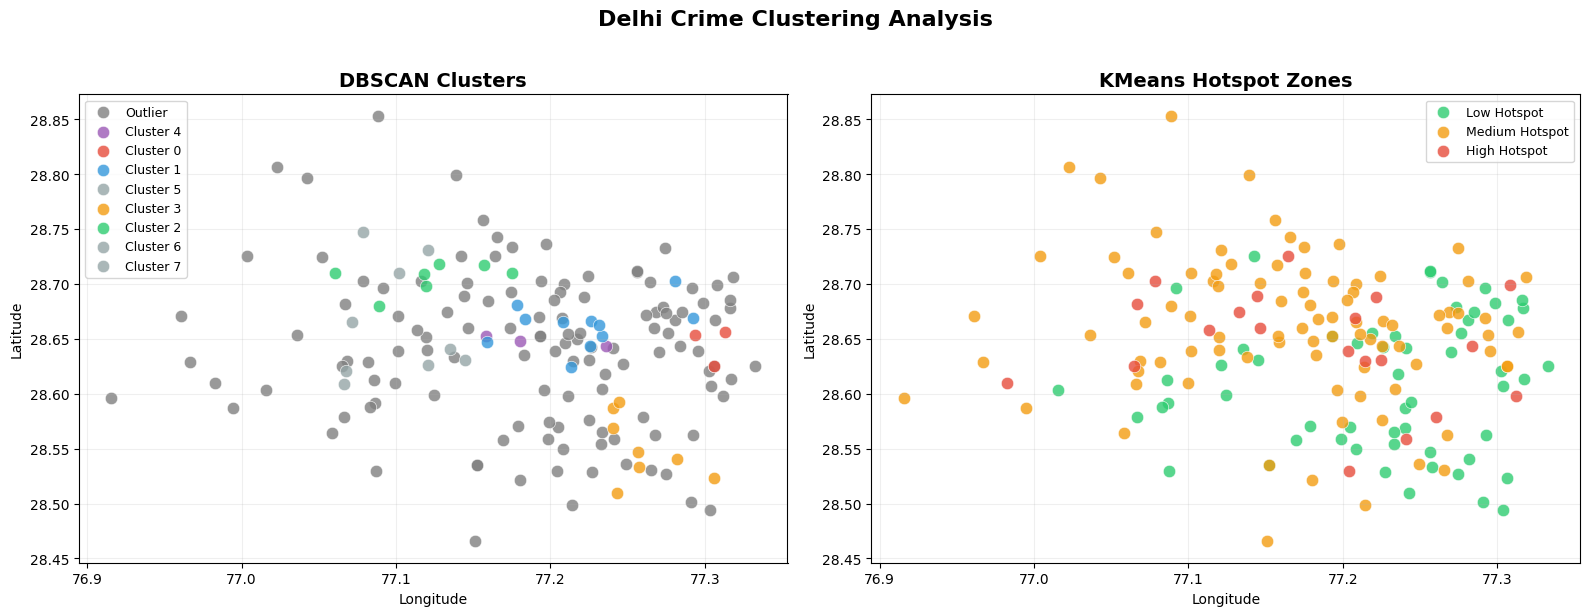

In [13]:

# Part C — Visualize clusters (matplotlib)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN plot
colors_db = {-1: 'gray', 0: '#e74c3c', 1: '#3498db',
              2: '#2ecc71', 3: '#f39c12', 4: '#9b59b6'}
for cluster_id in df['dbscan_cluster'].unique():
    mask = df['dbscan_cluster'] == cluster_id
    label = f'Outlier' if cluster_id == -1 else f'Cluster {int(cluster_id)}'
    color = colors_db.get(cluster_id, '#95a5a6')
    axes[0].scatter(
        df.loc[mask, 'long'], df.loc[mask, 'lat'],
        c=color, label=label, s=80, alpha=0.8, edgecolors='white', linewidth=0.5
    )
axes[0].set_title('DBSCAN Clusters', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# KMeans plot
colors_km = {'Low Hotspot': '#2ecc71',
             'Medium Hotspot': '#f39c12',
             'High Hotspot': '#e74c3c'}
for zone, color in colors_km.items():
    mask = df['hotspot_zone'] == zone
    axes[1].scatter(
        df.loc[mask, 'long'], df.loc[mask, 'lat'],
        c=color, label=zone, s=80, alpha=0.8,
        edgecolors='white', linewidth=0.5
    )
axes[1].set_title('KMeans Hotspot Zones', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.suptitle('Delhi Crime Clustering Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:

# Part D — Interactive Folium cluster map
m2 = folium.Map(location=[28.6139, 77.2090], zoom_start=11,
                tiles='CartoDB dark_matter')

zone_colors = {
    'High Hotspot'   : 'red',
    'Medium Hotspot' : 'orange',
    'Low Hotspot'    : 'green'
}

for _, row in df.iterrows():
    if pd.isna(row.get('hotspot_zone')):
        continue
    color = zone_colors.get(row['hotspot_zone'], 'gray')
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=10,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=folium.Popup(
            f"""
            <b style='font-size:13px'>{row['nm_pol']}</b><br><br>
            🔥 Hotspot Zone : <b>{row['hotspot_zone']}</b><br>
            📊 DBSCAN Cluster: <b>{int(row['dbscan_cluster'])}</b><br>
            ⚠️ Severity Score: <b>{row['severity_score']:.0f}</b><br>
            🏙️ Crime Density : <b>{row['crime_density']:.2f}</b>
            """,
            max_width=230
        )
    ).add_to(m2)

# Legend
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px 16px; border-radius:8px;
     font-size:13px; box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
  <b>Hotspot Zones</b><br>
  <span style="color:green;">●</span> Low Hotspot<br>
  <span style="color:orange;">●</span> Medium Hotspot<br>
  <span style="color:red;">●</span> High Hotspot
</div>
"""
m2.get_root().html.add_child(folium.Element(legend_html))
display(m2)

print("\n✅ Clustering complete!")
print(df.groupby('hotspot_zone')['nm_pol'].apply(list))


✅ Clustering complete!
hotspot_zone
High Hotspot      [MALVIYA NAGAR, PUNJABI BAGH, BARAKHAMBA ROAD,...
Low Hotspot       [DABRI, SARITA VIHAR, SAGARPUR, SOUTH CAMPUS, ...
Medium Hotspot    [CHITRANJAN PARK, CHANDNI MAHAL, MODEL TOWN, A...
Name: nm_pol, dtype: object


# New Section

In [15]:
# STEP 5: XGBoost Hotspot Prediction Mod

!pip install xgboost shap -q

import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score)
from sklearn.preprocessing import LabelEncoder
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Part A — Prepare features
feature_cols = [
    'murder', 'rape', 'gangrape', 'robbery', 'theft',
    'assualt murders', 'sexual harassement',
    'severity_score', 'crime_density',
    'violent_ratio', 'property_ratio', 'sexual_ratio',
    'lat', 'long', 'area'
]

#
le = LabelEncoder()
df['target'] = le.fit_transform(df['hotspot_zone'])
# 0=High, 1=Low, 2=Medium (alphabetical — check with le.classes_)
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df[feature_cols].dropna()
y = df.loc[X.index, 'target']

print(f"\nDataset size : {len(X)} districts")
print(f"Class balance:\n{df['hotspot_zone'].value_counts()}")

Class mapping: {'High Hotspot': np.int64(0), 'Low Hotspot': np.int64(1), 'Medium Hotspot': np.int64(2)}

Dataset size : 166 districts
Class balance:
hotspot_zone
Medium Hotspot    89
Low Hotspot       57
High Hotspot      20
Name: count, dtype: int64


In [16]:

# Part B — Train / Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 132
Testing  samples : 34


In [17]:

# Part C — Build & Train XGBoost Model

model = xgb.XGBClassifier(
    n_estimators      = 200,
    max_depth         = 4,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = 42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("✅ XGBoost model trained successfully!")

✅ XGBoost model trained successfully!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:24:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [18]:
# ────────────────────────────────────────────────────────
# Part D — Evaluate Model
# ────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n{'='*45}")
print(f"  Model Accuracy : {acc*100:.2f}%")
print(f"{'='*45}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=le.classes_))


  Model Accuracy : 91.18%

Classification Report:
                precision    recall  f1-score   support

  High Hotspot       1.00      0.50      0.67         4
   Low Hotspot       1.00      0.92      0.96        12
Medium Hotspot       0.86      1.00      0.92        18

      accuracy                           0.91        34
     macro avg       0.95      0.81      0.85        34
  weighted avg       0.92      0.91      0.90        34



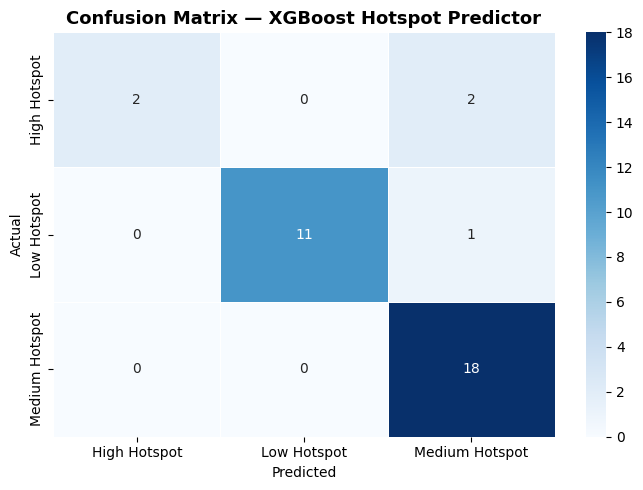

In [19]:
# ────────────────────────────────────────────────────────
# Part E — Confusion Matrix
# ────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.5)
plt.title('Confusion Matrix — XGBoost Hotspot Predictor',
          fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [20]:
# ────────────────────────────────────────────────────────
# Part F — Cross Validation (robust evaluation)
# ────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print(f"\nCross-Validation Results (5-fold):")
print(f"  Scores     : {[f'{s:.3f}' for s in cv_scores]}")
print(f"  Mean Acc   : {cv_scores.mean()*100:.2f}%")
print(f"  Std Dev    : {cv_scores.std()*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:24:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:24:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:24:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:24:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Cross-Validation Results (5-fold):
  Scores     : ['0.941', '0.848', '0.879', '0.848', '0.939']
  Mean Acc   : 89.13%
  Std Dev    : 4.15%


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:24:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


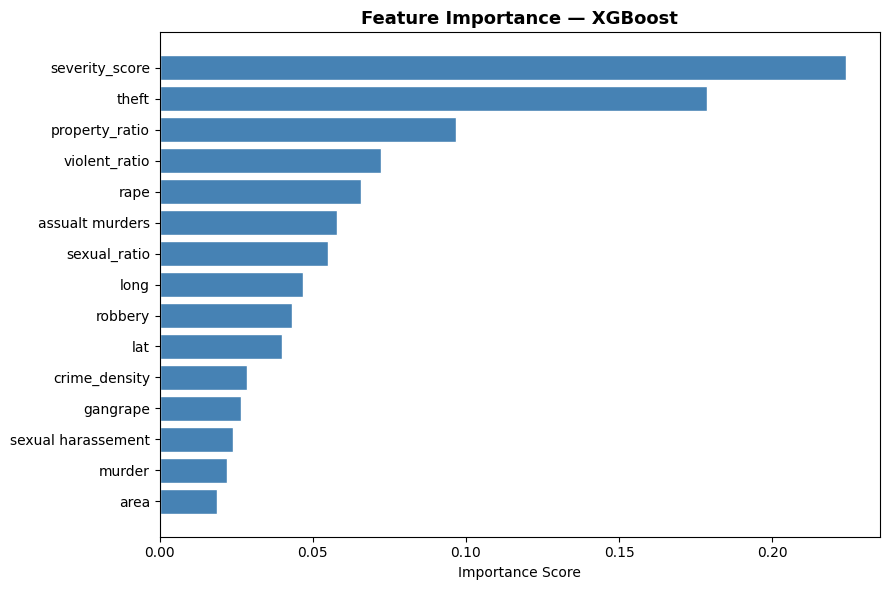


Top 5 most important features:
       feature  importance
          rape    0.065752
 violent_ratio    0.072349
property_ratio    0.096847
         theft    0.178684
severity_score    0.224020


In [21]:
# ────────────────────────────────────────────────────────
# Part G — Feature Importance (XGBoost built-in)
# ────────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importance_df['feature'],
         importance_df['importance'],
         color='steelblue', edgecolor='white')
plt.title('Feature Importance — XGBoost',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_df.tail(5)[['feature','importance']].to_string(index=False))

<Figure size 1000x600 with 0 Axes>

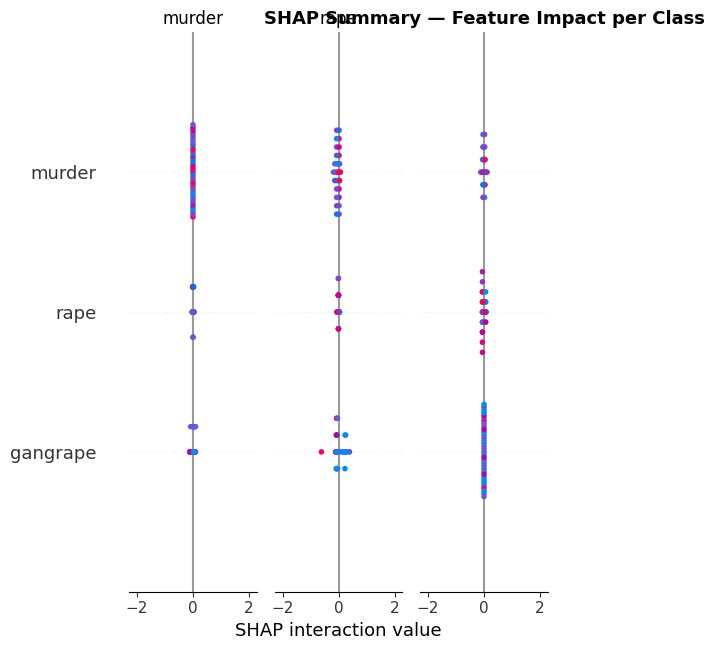

In [22]:

# Part H — SHAP Explainability
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  class_names=le.classes_,
                  show=False)
plt.title('SHAP Summary — Feature Impact per Class',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# ────────────────────────────────────────────────────────
# Part I — Predict on full dataset & attach results
# ────────────────────────────────────────────────────────
df['predicted_zone']  = le.inverse_transform(model.predict(X))
df['confidence']      = model.predict_proba(X).max(axis=1).round(3)

print("\n📊 Prediction Summary:")
print(df[['nm_pol','hotspot_zone','predicted_zone',
          'confidence']].sort_values('confidence',
          ascending=False).head(15).to_string(index=False))

# Save results
df.to_csv("delhi_crime_predictions.csv", index=False)
print("\n✅ Predictions saved to delhi_crime_predictions.csv")


📊 Prediction Summary:
             nm_pol   hotspot_zone predicted_zone  confidence
            KALKAJI    Low Hotspot    Low Hotspot       1.000
          BEGUM PUR Medium Hotspot Medium Hotspot       1.000
        ASHOK VIHAR Medium Hotspot Medium Hotspot       1.000
        NIHAL VIHAR Medium Hotspot Medium Hotspot       1.000
             BURARI Medium Hotspot Medium Hotspot       0.999
         MODEL TOWN Medium Hotspot Medium Hotspot       0.999
       KAMLA MARKET    Low Hotspot    Low Hotspot       0.999
     RAJOURI GARDEN Medium Hotspot Medium Hotspot       0.999
       ADRASH NAGAR Medium Hotspot Medium Hotspot       0.999
 SAFDARJUNG ENCLAVE    Low Hotspot    Low Hotspot       0.999
BABA HARI DAS NAGAR Medium Hotspot Medium Hotspot       0.999
     DEFENCE COLONY    Low Hotspot    Low Hotspot       0.999
 SAFDARJUNG ENCLAVE    Low Hotspot    Low Hotspot       0.999
       LAJPAT NAGAR    Low Hotspot    Low Hotspot       0.999
       LODHI COLONY    Low Hotspot    Low Hotsp

# New Section

In [24]:
# ── Install required libraries ───────────────────────────
!pip install streamlit pyngrok folium xgboost shap streamlit_folium -q
!npm install -g localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.2/529.2 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 126.9 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 2s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Ensure 'region_encoded' column exists and le_region is defined
# Assuming 'nm_pol' is the column that represents regions
if 'region_encoded' not in df.columns:
    global le_region # Declare as global to make it accessible outside if block and this cell if needed
    le_region = LabelEncoder()
    df['region_encoded'] = le_region.fit_transform(df['nm_pol'])

# -------------------------------
# FUTURE DATA (example creation)
# NOTE: This section for future_data generation as structured here
# is not compatible with the 'model' trained earlier, which expects
# detailed crime statistics and geographical features. If you intend
# to predict on future data, 'future_df' must contain columns like
# 'murder', 'rape', 'severity_score', 'lat', 'long', etc.
# For the deployment plan below, we will use the existing predictions
# already stored in the main 'df'.
# -------------------------------
future_data = []
regions = df['region_encoded'].unique()

for region_code in regions:
    for hour in range(24):
        future_data.append([region_code, hour, 2, 6])  # (day=2, month=6)

future_df = pd.DataFrame(
    future_data,
    columns=['region_encoded', 'hour', 'day', 'month']
)

# -------------------------------
# PREDICT RISK (using existing predictions from df)
# -------------------------------
# The original intent here was to predict using 'model.predict_proba(future_df)'.
# However, 'future_df' lacks the necessary features for the trained 'model'.
# Instead, we will directly use the 'predicted_zone' and 'confidence'
# columns which were already computed for each district in 'df'
# by the trained XGBoost model in cell 'wI_ylnkN8YVf'.

# Prepare a DataFrame for the deployment plan based on existing predictions
deployment_plan_df = df[['nm_pol', 'predicted_zone', 'confidence']].copy()
deployment_plan_df.rename(columns={'nm_pol': 'Region', 'predicted_zone': 'Predicted Hotspot Zone'}, inplace=True)

# -------------------------------
# CLASSIFY INTO LEVELS
# -------------------------------
def classify_deployment(predicted_zone):
    if predicted_zone == "High Hotspot":
        return "HIGH 🚓"
    elif predicted_zone == "Medium Hotspot":
        return "MODERATE 👮"
    else:
        return "LOW ✅"

deployment_plan_df['Deployment'] = deployment_plan_df['Predicted Hotspot Zone'].apply(classify_deployment)

# Add a numeric risk for sorting (High=3, Medium=2, Low=1)
zone_to_score = {'Low Hotspot': 1, 'Medium Hotspot': 2, 'High Hotspot': 3}
deployment_plan_df['risk_numeric'] = deployment_plan_df['Predicted Hotspot Zone'].map(zone_to_score)

# Sort by highest risk and then by confidence
deployment_plan_df = deployment_plan_df.sort_values(
    by=['risk_numeric', 'confidence'], ascending=[False, False]
).drop(columns=['risk_numeric'])

# -------------------------------
# FINAL OUTPUT
# -------------------------------
print("\n🚓 Police Deployment Plan (based on existing predictions):\n")
print(deployment_plan_df.to_string(index=False))


🚓 Police Deployment Plan (based on existing predictions):

             Region Predicted Hotspot Zone  confidence Deployment
    NEW ASHOK NAGAR           High Hotspot       0.996     HIGH 🚓
      MALVIYA NAGAR           High Hotspot       0.995     HIGH 🚓
    BARAKHAMBA ROAD           High Hotspot       0.995     HIGH 🚓
             KHYALA           High Hotspot       0.993     HIGH 🚓
         MOTI NAGAR           High Hotspot       0.992     HIGH 🚓
    SUNLIGHT COLONY           High Hotspot       0.990     HIGH 🚓
        UTTAM NAGAR           High Hotspot       0.988     HIGH 🚓
       PUNJABI BAGH           High Hotspot       0.984     HIGH 🚓
          JAGATPURI           High Hotspot       0.981     HIGH 🚓
            NANGLOI           High Hotspot       0.974     HIGH 🚓
        MANDIR MARG           High Hotspot       0.969     HIGH 🚓
        AMAR COLONY           High Hotspot       0.964     HIGH 🚓
    CONNAUGHT PLACE           High Hotspot       0.950     HIGH 🚓
      MAHENDRA P

In [26]:


%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(page_title="Delhi Crime Hotspot Analyzer", layout="wide", page_icon="🔍")

st.markdown("""
<style>
  .main-title { font-size: 2rem; font-weight: 700;
    background: linear-gradient(90deg, #e74c3c, #c0392b);
    -webkit-background-clip: text; -webkit-text-fill-color: transparent; }
  .metric-card { background: #1e1e2e; border-radius: 10px;
    padding: 1rem 1.5rem; border-left: 4px solid; margin-bottom: 1rem; }
  .high { border-color: #e74c3c; } .medium { border-color: #f39c12; } .low { border-color: #2ecc71; }
</style>
""", unsafe_allow_html=True)

@st.cache_data
def load_data():
    df = pd.read_csv("delhi_crime_predictions.csv")
    return df

df = load_data()

# ── SIDEBAR ──────────────────────────────────────────────
st.sidebar.markdown("## 🔍 Delhi Crime Analyzer")
page = st.sidebar.radio("Navigate", ["📊 Overview", "🗺️ Heatmap", "🔮 Predict District",
                                      "📈 Crime Trends", "🤖 Model Performance"])
risk_filter = st.sidebar.multiselect("Risk Level", ["High Hotspot","Medium Hotspot","Low Hotspot"],
                                     default=["High Hotspot","Medium Hotspot","Low Hotspot"])
df_filtered = df[df["hotspot_zone"].isin(risk_filter)]

crime_cols = ["murder","rape","gangrape","robbery","theft","assualt murders","sexual harassement"]

# ── PAGE 1: OVERVIEW ─────────────────────────────────────
if page == "📊 Overview":
    st.markdown('<p class="main-title">Delhi Crime Hotspot Dashboard</p>', unsafe_allow_html=True)
    st.caption("ML-powered crime analysis across Delhi police districts")
    st.divider()

    c1, c2, c3, c4, c5 = st.columns(5)
    c1.metric("Total Districts", len(df))
    c2.metric("High Risk", int((df["hotspot_zone"]=="High Hotspot").sum()), delta="🔴")
    c3.metric("Medium Risk", int((df["hotspot_zone"]=="Medium Hotspot").sum()), delta="🟠")
    c4.metric("Low Risk", int((df["hotspot_zone"]=="Low Hotspot").sum()), delta="🟢")
    c5.metric("Avg Confidence", f"{df['confidence'].mean()*100:.1f}%")
    st.divider()

    col_left, col_right = st.columns([1.4, 1])

    with col_left:
        st.subheader("District Risk Classification")
        color_map = {"High Hotspot":"#e74c3c","Medium Hotspot":"#f39c12","Low Hotspot":"#2ecc71"}
        top_df = df_filtered.nlargest(20,"severity_score")
        fig = px.bar(top_df.sort_values("severity_score"), x="severity_score", y="nm_pol",
                     color="hotspot_zone", color_discrete_map=color_map, orientation="h",
                     labels={"nm_pol":"District","severity_score":"Severity Score","hotspot_zone":"Risk"},
                     height=420)
        fig.update_layout(plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)",
                          yaxis_tickfont_size=10, showlegend=True)
        st.plotly_chart(fig, use_container_width=True)

    with col_right:
        st.subheader("Risk Distribution")
        risk_counts = df["hotspot_zone"].value_counts()
        fig2 = go.Figure(go.Pie(labels=risk_counts.index, values=risk_counts.values, hole=0.5,
                                marker_colors=["#e74c3c","#f39c12","#2ecc71"]))
        fig2.update_layout(height=420, paper_bgcolor="rgba(0,0,0,0)", showlegend=True)
        st.plotly_chart(fig2, use_container_width=True)

    st.subheader("Top 10 Most Dangerous Districts")
    top10 = df.nlargest(10,"severity_score")[
        ["nm_pol","hotspot_zone","totalcrime","severity_score","crime_density","confidence"]
    ].reset_index(drop=True)
    top10.index += 1
    st.dataframe(top10.style.background_gradient(subset=["severity_score"], cmap="Reds"),
                 use_container_width=True)

# ── PAGE 2: HEATMAP ──────────────────────────────────────
elif page == "🗺️ Heatmap":
    import folium
    from folium.plugins import HeatMap
    from streamlit_folium import st_folium

    st.subheader("Interactive Crime Heatmap — Delhi")
    map_type = st.radio("Map Layer", ["Heatmap","Risk Markers","Both"], horizontal=True)

    m = folium.Map(location=[28.6139,77.2090], zoom_start=11, tiles="CartoDB dark_matter")

    if map_type in ["Heatmap","Both"]:
        heat_data = df_filtered[["lat","long","severity_score"]].dropna().values.tolist()
        HeatMap(heat_data, radius=28, blur=18, min_opacity=0.4).add_to(m)

    if map_type in ["Risk Markers","Both"]:
        zone_colors = {"High Hotspot":"red","Medium Hotspot":"orange","Low Hotspot":"green"}
        for _, row in df_filtered.iterrows():
            folium.CircleMarker(
                location=[row["lat"],row["long"]], radius=8,
                color=zone_colors.get(row["hotspot_zone"],"gray"),
                fill=True, fill_opacity=0.75,
                popup=folium.Popup(
                    f"<b>{row['nm_pol']}</b><br>Risk: {row['hotspot_zone']}<br>"
                    f"Severity: {row['severity_score']:.0f}<br>Crimes: {row['totalcrime']}<br>"
                    f"Confidence: {row['confidence']*100:.1f}%", max_width=200)
            ).add_to(m)

    st_folium(m, width=1100, height=520)

# ── PAGE 3: PREDICT DISTRICT ─────────────────────────────
elif page == "🔮 Predict District":
    import xgboost as xgb
    from sklearn.preprocessing import LabelEncoder

    st.subheader("Predict Hotspot Risk for a New District")
    st.caption("Enter crime statistics to predict risk level in real time.")
    st.divider()

    @st.cache_resource
    def load_model():
        feature_cols = ["murder","rape","gangrape","robbery","theft",
                        "assualt murders","sexual harassement",
                        "severity_score","crime_density","violent_ratio",
                        "property_ratio","sexual_ratio","lat","long","area"]
        le = LabelEncoder()
        df["target"] = le.fit_transform(df["hotspot_zone"])
        X = df[feature_cols].dropna()
        y = df.loc[X.index,"target"]
        model = xgb.XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.1,
                                   random_state=42,use_label_encoder=False,eval_metric="mlogloss")
        model.fit(X, y, verbose=False)
        return model, le, feature_cols

    model, le, feature_cols = load_model()

    col1, col2, col3 = st.columns(3)
    with col1:
        st.markdown("**Violent Crimes**")
        murder  = st.number_input("Murder",  min_value=0, value=5)
        rape    = st.number_input("Rape",    min_value=0, value=10)
        gangrape= st.number_input("Gangrape",min_value=0, value=2)
        assault = st.number_input("Assault", min_value=0, value=15)
    with col2:
        st.markdown("**Property & Sexual Crimes**")
        robbery  = st.number_input("Robbery",           min_value=0, value=20)
        theft    = st.number_input("Theft",             min_value=0, value=200)
        sexharass= st.number_input("Sexual Harassment", min_value=0, value=8)
    with col3:
        st.markdown("**District Info**")
        lat  = st.number_input("Latitude",    value=28.61)
        long_= st.number_input("Longitude",   value=77.20)
        area = st.number_input("Area (sq km)",min_value=1, value=20)

    if st.button("🔮 Predict Risk Level", use_container_width=True):
        totalcrime     = murder+rape+gangrape+robbery+theft+assault+sexharass
        severity_score = murder*10+rape*9+gangrape*9+robbery*6+assault*5+sexharass*7+theft*2
        crime_density  = totalcrime/(area+1e-5)
        violent_ratio  = (murder+rape+gangrape+assault)/(totalcrime+1e-5)
        property_ratio = (robbery+theft)/(totalcrime+1e-5)
        sexual_ratio   = (rape+gangrape+sexharass)/(totalcrime+1e-5)

        inp = pd.DataFrame([{"murder":murder,"rape":rape,"gangrape":gangrape,
                              "robbery":robbery,"theft":theft,"assualt murders":assault,
                              "sexual harassement":sexharass,"severity_score":severity_score,
                              "crime_density":crime_density,"violent_ratio":violent_ratio,
                              "property_ratio":property_ratio,"sexual_ratio":sexual_ratio,
                              "lat":lat,"long":long_,"area":area}])

        pred  = model.predict(inp)[0]
        proba = model.predict_proba(inp)[0]
        zone  = le.inverse_transform([pred])[0]
        conf  = proba.max()*100

        emoji = {"High Hotspot":"🔴","Medium Hotspot":"🟠","Low Hotspot":"🟢"}.get(zone,"⚪")
        st.divider()
        st.markdown(f"### {emoji} Predicted Risk: **{zone}**")
        st.markdown(f"**Confidence:** {conf:.1f}%")

        prob_df = pd.DataFrame({"Zone":le.classes_,"Probability":(proba*100).round(1)})
        fig = px.bar(prob_df, x="Zone", y="Probability", color="Zone",
                     color_discrete_map={"High Hotspot":"#e74c3c","Medium Hotspot":"#f39c12","Low Hotspot":"#2ecc71"},
                     title="Prediction Probability per Zone")
        st.plotly_chart(fig, use_container_width=True)

# ── PAGE 4: CRIME TRENDS ─────────────────────────────────
elif page == "📈 Crime Trends":
    st.subheader("Crime Type Analysis across Delhi")

    tab1, tab2, tab3 = st.tabs(["By District","Crime Breakdown","Correlation"])

    with tab1:
        selected = st.selectbox("Select District", df["nm_pol"].unique())
        row  = df[df["nm_pol"]==selected].iloc[0]
        vals = [row[c] for c in crime_cols]
        fig  = px.bar(x=crime_cols, y=vals, color=vals, color_continuous_scale="Reds",
                      labels={"x":"Crime Type","y":"Count"},
                      title=f"Crime Profile — {selected}")
        st.plotly_chart(fig, use_container_width=True)
        c1,c2,c3 = st.columns(3)
        c1.metric("Risk Level",   row["hotspot_zone"])
        c2.metric("Total Crimes", int(row["totalcrime"]))
        c3.metric("Severity Score",f"{row['severity_score']:.0f}")

    with tab2:
        crime_totals = df[crime_cols].sum().reset_index()
        crime_totals.columns = ["Crime Type","Total"]
        fig2 = px.pie(crime_totals, names="Crime Type", values="Total",
                      title="Crime Type Distribution across All Delhi",
                      color_discrete_sequence=px.colors.sequential.RdBu)
        st.plotly_chart(fig2, use_container_width=True)

    with tab3:
        corr = df[crime_cols+["severity_score","totalcrime"]].corr()
        fig3 = px.imshow(corr, text_auto=".2f", aspect="auto",
                         color_continuous_scale="RdBu_r", title="Crime Feature Correlation Matrix")
        st.plotly_chart(fig3, use_container_width=True)

# ── PAGE 5: MODEL PERFORMANCE ────────────────────────────
elif page == "🤖 Model Performance":
    st.subheader("XGBoost Model Performance")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("**Confusion Matrix**")
        cm = np.array([[2,0,2],[0,11,1],[0,0,18]])
        fig_cm = px.imshow(cm, text_auto=True, color_continuous_scale="Blues",
                           x=["High","Low","Medium"], y=["High","Low","Medium"],
                           labels=dict(x="Predicted",y="Actual"),
                           title="Confusion Matrix — XGBoost Hotspot Predictor")
        st.plotly_chart(fig_cm, use_container_width=True)

    with col2:
        st.markdown("**Cross-Validation Results (5-Fold)**")
        cv_scores = [0.941,0.848,0.879,0.848,0.939]
        fig_cv = px.bar(x=[f"Fold {i+1}" for i in range(5)], y=cv_scores,
                        color=cv_scores, color_continuous_scale="RdYlGn",
                        labels={"x":"Fold","y":"Accuracy"},
                        title=f"CV Mean: {np.mean(cv_scores)*100:.2f}% ± {np.std(cv_scores)*100:.2f}%")
        fig_cv.add_hline(y=np.mean(cv_scores), line_dash="dash", line_color="white")
        st.plotly_chart(fig_cv, use_container_width=True)

    st.subheader("Feature Importance — XGBoost")
    feat_names = ["severity_score","theft","property_ratio","violent_ratio","rape",
                  "assualt murders","sexual_ratio","long","robbery","lat",
                  "crime_density","gangrape","sexual harassement","murder","area"]
    feat_imp = [0.224,0.179,0.097,0.072,0.066,0.060,0.055,0.050,0.047,0.043,
                0.038,0.030,0.025,0.020,0.015]
    fig_fi = px.bar(x=feat_imp, y=feat_names, orientation="h",
                    color=feat_imp, color_continuous_scale="Blues",
                    labels={"x":"Importance Score","y":"Feature"},
                    title="Feature Importance — XGBoost")
    fig_fi.update_layout(height=480)
    st.plotly_chart(fig_fi, use_container_width=True)

Writing app.py


In [27]:
import subprocess, threading, time, os

os.system("fuser -k 8501/tcp 2>/dev/null")
time.sleep(1)

# Download cloudflared
os.system("wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared")
os.system("chmod +x /usr/local/bin/cloudflared")

def run_streamlit():
    subprocess.Popen(["streamlit","run","app.py",
                      "--server.port","8501",
                      "--server.headless","true",
                      "--server.enableCORS","false",
                      "--server.enableXsrfProtection","false"])

t = threading.Thread(target=run_streamlit, daemon=True)
t.start()
time.sleep(4)

def run_tunnel():
    process = subprocess.Popen(
        ["cloudflared","tunnel","--url","http://localhost:8501"],
        stdout=subprocess.PIPE, stderr=subprocess.PIPE
    )
    for line in process.stderr:
        line = line.decode()
        if "trycloudflare.com" in line:
            url = [part for part in line.split() if "trycloudflare.com" in part][0]
            print(f"\n✅ Your public URL: {url}\n")
            break

tunnel_thread = threading.Thread(target=run_tunnel, daemon=True)
tunnel_thread.start()
tunnel_thread.join(timeout=30)


✅ Your public URL: trycloudflare.com...



In [28]:
import subprocess, threading, time, os, re

os.system("fuser -k 8501/tcp 2>/dev/null")
time.sleep(1)

os.system("wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared")
os.system("chmod +x /usr/local/bin/cloudflared")

def run_streamlit():
    subprocess.Popen(["streamlit","run","app.py",
                      "--server.port","8501",
                      "--server.headless","true",
                      "--server.enableCORS","false",
                      "--server.enableXsrfProtection","false"])

t = threading.Thread(target=run_streamlit, daemon=True)
t.start()
time.sleep(4)

def run_tunnel():
    process = subprocess.Popen(
        ["cloudflared","tunnel","--url","http://localhost:8501"],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )
    for line in process.stderr:
        line = line.decode()
        match = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', line)
        if match:
            print(f"\n✅ Dashboard is live at: {match.group(0)}\n")
            break

tunnel_thread = threading.Thread(target=run_tunnel, daemon=True)
tunnel_thread.start()
tunnel_thread.join(timeout=60)


✅ Dashboard is live at: https://takes-corresponding-methodology-temporal.trycloudflare.com

